# Gradient Boosted Machines - Global Interpretation
- Notebook completed by Adam Lang
- This is from the train in data course by Soledad Galli, PhD, which I highly recommend taking to enhance your ML explainability skills.
- Date: 8-18-2026

## Imports

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns

## sklearn imports
from sklearn.datasets import fetch_california_housing ## dataset
from sklearn.ensemble import GradientBoostingRegressor ## Regression GBM
from sklearn.model_selection import train_test_split

## Load Data from sklearn

In [6]:
## lets load the dataset
cali_housing = fetch_california_housing
cali_housing

<function sklearn.datasets._california_housing.fetch_california_housing(*, data_home=None, download_if_missing=True, return_X_y=False, as_frame=False, n_retries=3, delay=1.0)>

In [7]:
## put into X,y split for preprocessing
X, y = fetch_california_housing(return_X_y=True,
                                as_frame=True)
X = X.drop(columns=["Latitude","Longitude"])

## display top rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467


## Data Viz

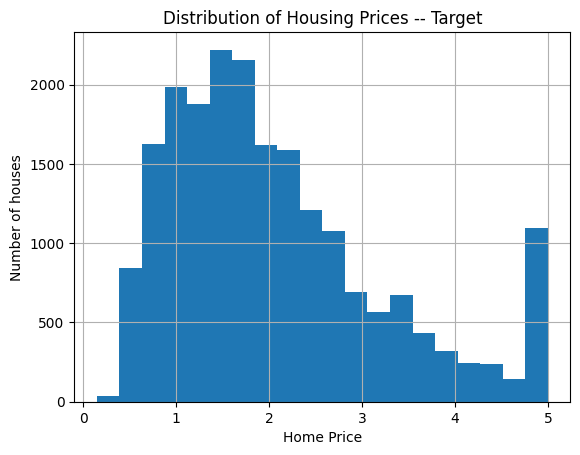

In [8]:
## view target distribution
y.hist(bins=20)
plt.xlabel("Home Price")
plt.ylabel("Number of houses")
plt.title("Distribution of Housing Prices -- Target")
plt.show();

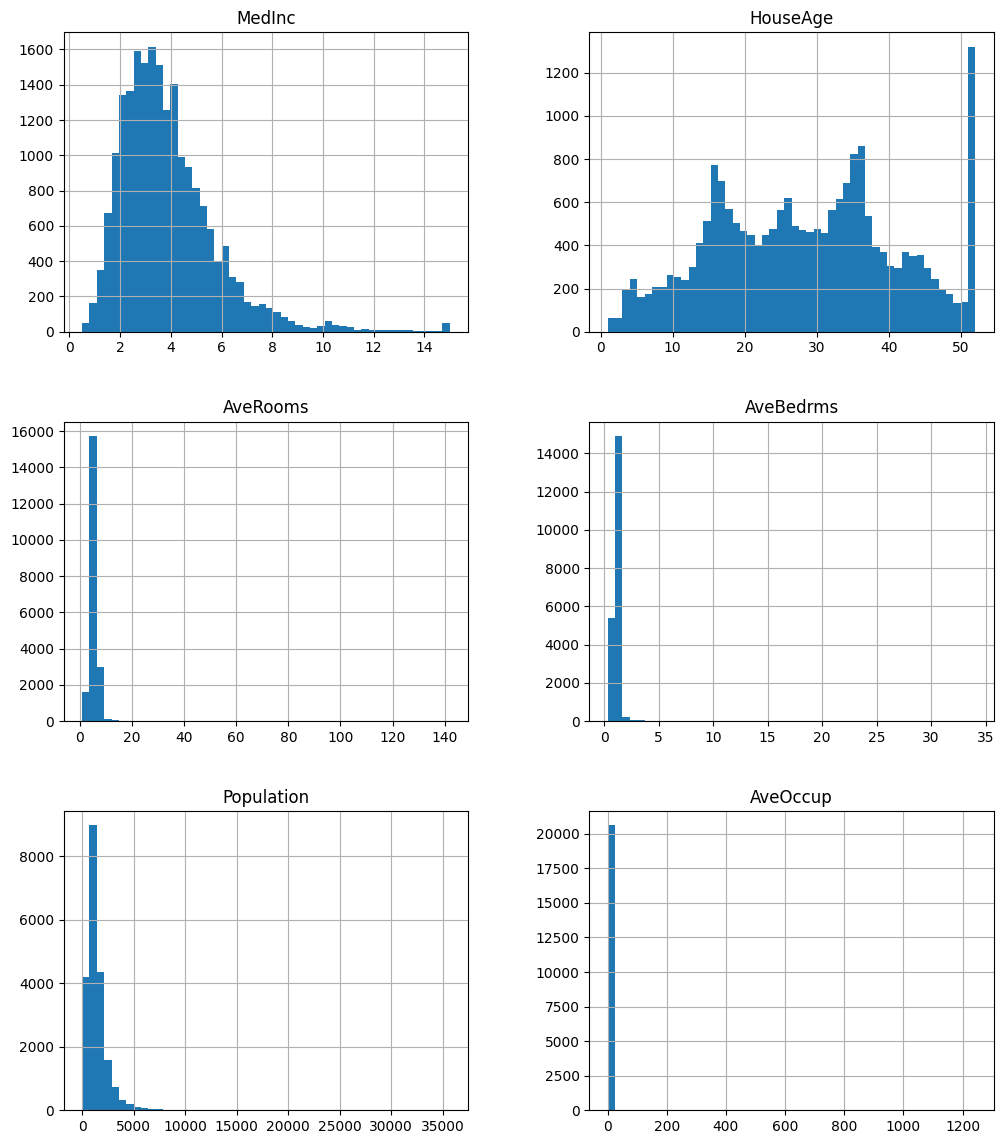

In [10]:
## display variables distribution
X.hist(bins=50, figsize=(12,14))
plt.show();

## Train-Test Split

In [11]:
## train-test split for model train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


## shape
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14448, 6)
X_test shape: (6192, 6)


## Gradient Boosting Regressor
- now we can fit the model
- Note about the criterion it is either of these:

1. friedman mse
2. sum of squares

- key differences:
  - **Standard Sum of Squares (MSE/Variance Reduction)**: Measures impurity by calculating the traditional variance or squared error reduction \(\sum (y_i - \bar{y})^2\) for a node split.
  
  - **Friedman's MSE (friedman_mse)**: Uses a modified impurity-improvement calculation derived by Jerome Friedman in his original gradient boosting paper to account for the specific gradient-matching steps of the boosting process.
  
- **Performance Impact**: Friedman's MSE can provide a slightly better split approximation for gradient boosting structures, though discussions note they are mathematically close or equivalent in functionality, which is why scikit-learn deprecated the explicit criterion toggle in newer versions.
- see docs: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

In [12]:
## fit model
gbm = GradientBoostingRegressor(
    criterion="friedman_mse",
    n_estimators=50, ## num of trees to boost
    max_depth=3, ## control for overfitting
    random_state=3,
)
gbm.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=50, random_state=3)

### Eval model on train and test set

In [13]:
## R2 in train set
gbm.score(X_train, y_train)

0.6924967747593357

In [14]:
## R2 in test set
gbm.score(X_test, y_test)

0.6660886342834671

### Summary
- We can say that the GBM regressor explains more than 60% of the variability in the target variable.

## Global explainations -- feature importance
- We do this by adding up the GAIN throughout all the nodes in the trees by sklearn.

In [16]:
## gbm regressor importance
global_exp = pd.Series(gbm.feature_importances_,
                       index=gbm.feature_names_in_)

global_exp

,0
MedInc,0.730024
HouseAge,0.064886
AveRooms,0.039567
AveBedrms,0.008564
Population,0.005443
AveOccup,0.151517


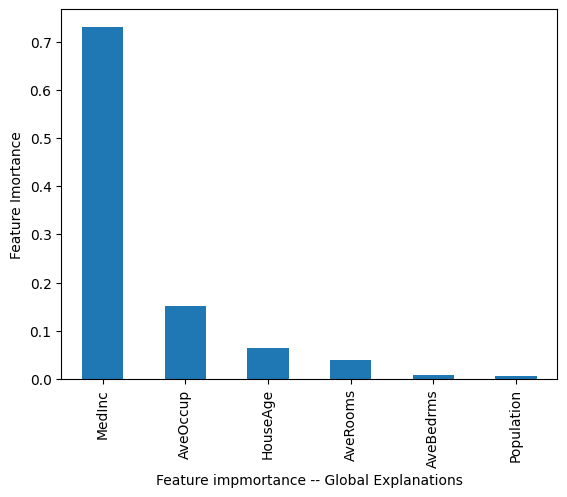

In [20]:
## plot this -- sort in descending order
global_exp.sort_values(ascending=False).plot.bar()
plt.ylabel("Feature Imortance")
plt.xlabel("Feature impmortance -- Global Explanations")
plt.show();

### Summary
- We can see that median income is the most important feature based on the global explanation, followed by ave occup, and house age.
- This model is quite different than if you were to train a Random Forest or Decision Tree model -- the features that are important here will not be important there.

- **Why? Multicollinearity effects feature importance returned by the gradient boosted trees.**
  - GBMs (trees) severely alters global feature importance calculations by diluting, masking, or artificially altering the importance scores across correlated variables. Because tree-based models make greedy, step-wise splits based on individual features, redundant information disrupts how credit is assigned

### How to Fix multicollinearity in GBMs?
1. Pre-filter with VIF -- remove features with a high Variance Inflation Factor (VIF)

2. Hierarchical clustering -- group correlated features using dendograms and keep only 1 representative from each cluster (or perhaps another clustering algo).

3. Use SHAP values -- TreeSHAP handles multicollinearity more consistently by re-distributing importance across correlated features based on game theory, but interpretation can be difficult.
- See this article for more: https://medium.com/@mishra12486/understanding-multicollinearity-impact-and-mitigation-across-machine-learning-algorithms-636aa8018cb7